# Tokenization & Embeddings Deep Dive using Azure AI Services

In this lab, you will build a clear, practical understanding of how **tokenisation** and **embeddings** power modern LLM workflows. We’ll start by demystifying how text is broken into tokens, why token counts affect cost, latency, and context limits, and how to design token-aware inputs (including safe chunking strategies). Then we’ll deep dive into embeddings as dense vector representations of meaning—how they’re generated, how similarity (especially cosine similarity) is computed, and how this enables semantic search, clustering, and retrieval for RAG systems. Expect a blend of concise theory and hands-on exercises: inspecting tokens, measuring token budgets, generating embeddings with Azure OpenAI, comparing vectors, and building a small semantic retrieval pipeline with validation checkpoints at each stage.


## Learning goals
By the end of this lab, you will be able to:
- Explain how modern tokenizers (BPE-like) convert text into tokens and why it matters.
- Measure token counts and design safe chunking strategies for long documents.
- Generate embeddings using **Azure OpenAI** and interpret them as vectors.
- Compute similarity (cosine) and build a small semantic search over a corpus.

## Estimated time
~90–120 minutes (depending on optional sections).

## Safety note (important)
- **Do not hardcode API keys** in notebooks.
- Use environment variables or Azure Key Vault.
- If an API key was ever pasted into chat or a notebook, **rotate it immediately**.


## 0) Setup

### 0.1 Install dependencies
We’ll use:
- `openai` (AzureOpenAI client)
- `tiktoken` (token counting / token inspection)
- `numpy`, `pandas` (vector math + display)
- `scikit-learn` (optional: nearest neighbors / PCA)

> If you’re on a hosted Jupyter environment, you may need to restart the kernel after installs.


In [1]:
%pip install -q --upgrade openai tiktoken numpy pandas scikit-learn matplotlib python-dotenv

Note: you may need to restart the kernel to use updated packages.


### 0.2 Configure environment variables (recommended)

Set these in your shell / notebook environment **before** running the rest of the notebook:

- `AZURE_OPENAI_ENDPOINT` → e.g., `https://<your-resource-name>.openai.azure.com/`
- `AZURE_OPENAI_API_KEY` → one of your resource keys
- `AZURE_OPENAI_EMBEDDINGS_DEPLOYMENT` → your deployment name (e.g., `text-embedding-ada-002`)
- `AZURE_OPENAI_CHAT_DEPLOYMENT` → your chat deployment name (e.g., `gpt-4o-mini`)

> In Azure OpenAI, the `model` parameter is typically your **deployment name**, not the base model family name.


In [ ]:
import os

AZURE_OPENAI_ENDPOINT = os.getenv('AZURE_OPENAI_ENDPOINT', 'https://<TBD>.cognitiveservices.azure.com/').strip()
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY', '').strip()
EMBEDDINGS_DEPLOYMENT = os.getenv('AZURE_OPENAI_EMBEDDINGS_DEPLOYMENT', 'text-embedding-ada-002')
CHAT_DEPLOYMENT = os.getenv('AZURE_OPENAI_CHAT_DEPLOYMENT', 'gpt-4o')

missing = [k for k,v in {
    'AZURE_OPENAI_ENDPOINT': AZURE_OPENAI_ENDPOINT,
    'AZURE_OPENAI_API_KEY': AZURE_OPENAI_API_KEY,
}.items() if not v]

if missing:
    print('Missing environment variables:', ', '.join(missing))
    print('Set them before continuing. Example:')
    print('  export AZURE_OPENAI_ENDPOINT="https://<resource>.openai.azure.com/"')
    print('  export AZURE_OPENAI_API_KEY="<key>"')
else:
    print('Environment variables detected.')
    print('Embeddings deployment:', EMBEDDINGS_DEPLOYMENT)
    print('Chat deployment:', CHAT_DEPLOYMENT)

Environment variables detected.
Embeddings deployment: text-embedding-ada-002
Chat deployment: gpt-4o


### 0.3 Create the AzureOpenAI client

We’ll use the OpenAI Python SDK’s `AzureOpenAI` client.

> Use a stable API version supported by your Azure OpenAI resource. If your org standardizes a version, keep it consistent across labs.


In [3]:
from openai import AzureOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

# Choose an API version supported by your Azure OpenAI resource.
# Commonly used examples include 2024-02-01, 2024-06-01, or preview versions.
API_VERSION = os.getenv('AZURE_OPENAI_API_VERSION', '"2024-12-01-preview"')

client = AzureOpenAI(
    api_version=API_VERSION,
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
)

print('AzureOpenAI client created with API version:', API_VERSION)

AzureOpenAI client created with API version: 2024-12-01-preview


### 0.4 Quick connectivity check (embeddings)

We’ll embed a tiny string and verify:
- request succeeds
- embedding vector is returned
- we can read the vector length


In [4]:
import numpy as np

test_text = "Hello embeddings!"
resp = client.embeddings.create(
    model=EMBEDDINGS_DEPLOYMENT,
    input=[test_text],
)
vec = np.array(resp.data[0].embedding, dtype=np.float32)

print('Embedding generated')
print('Vector shape:', vec.shape)
print('First 8 dims:', vec[:8])

Embedding generated
Vector shape: (1536,)
First 8 dims: [-0.02950904 -0.01328439  0.00810235 -0.03467113 -0.01973035  0.00290367
  0.00539491 -0.00797596]


# 1) Tokenization Deep Dive

## 1.1 What is tokenization?
Large language models don’t read raw characters. They process **tokens** — chunks of text produced by a tokenizer.

Why you care:
- **Cost & latency** scale with token count.
- Context windows are measured in tokens.
- Chunking for RAG and indexing is usually done by tokens (not characters).

## 1.2 How BPE-like tokenization works (intuition)
Most modern tokenizers are variants of **Byte Pair Encoding (BPE)**.
- Start with bytes (or characters) and merge frequent pairs into larger units.
- Common words become single tokens; rarer strings become multiple tokens.
- Spaces often attach to the next word (e.g., tokens like `" is"`).

Practical consequences:
- Token boundaries don’t match word boundaries.
- Non-English scripts and emojis can tokenize differently.
- Minor formatting changes (extra whitespace/newlines) can change token counts.


## 1.3 Hands-on: inspect tokens with `tiktoken`

Different models can use different encodings.
- `gpt-4o-mini` uses `o200k_base`.
- Many embeddings models (including `text-embedding-ada-002`) use `cl100k_base`.

We’ll:
1) Load model-specific encodings
2) Encode sample strings
3) Decode tokens back to readable text


In [5]:
%pip install -U tiktoken

import tiktoken

enc_chat = tiktoken.encoding_for_model('gpt-4o-mini')
enc_embed = tiktoken.get_encoding('cl100k_base')  # embeddings family uses cl100k_base

print('Chat encoding:', enc_chat.name)
print('Embeddings encoding:', enc_embed.name)

Note: you may need to restart the kernel to use updated packages.
Chat encoding: o200k_base
Embeddings encoding: cl100k_base


In [6]:
def show_tokens(text: str, encoding) -> None:
    token_ids = encoding.encode(text)
    pieces = [encoding.decode([tid]) for tid in token_ids]
    print('TEXT:', repr(text))
    print('TOKENS:', len(token_ids))
    for i, (tid, p) in enumerate(zip(token_ids, pieces), start=1):
        print(f"{i:02d}  {tid:>6}  {repr(p)}")

samples = [
    "tiktoken is great!",
    "Hello, world!",
    "Azure OpenAI embeddings are useful for semantic search.",
    "नमस्ते दुनिया 🌍(emoji)",
    "Tabs\tand\nnewlines\nchange tokenization.",
]

for s in samples:
    print('\n' + '='*80)
    show_tokens(s, enc_embed)


TEXT: 'tiktoken is great!'
TOKENS: 6
01      83  't'
02    1609  'ik'
03    5963  'token'
04     374  ' is'
05    2294  ' great'
06       0  '!'

TEXT: 'Hello, world!'
TOKENS: 4
01    9906  'Hello'
02      11  ','
03    1917  ' world'
04       0  '!'

TEXT: 'Azure OpenAI embeddings are useful for semantic search.'
TOKENS: 10
01   79207  'Azure'
02    5377  ' Open'
03   15836  'AI'
04   71647  ' embeddings'
05     527  ' are'
06    5505  ' useful'
07     369  ' for'
08   42833  ' semantic'
09    2778  ' search'
10      13  '.'

TEXT: 'नमस्ते दुनिया 🌍(emoji)'
TOKENS: 19
01   61196  'न'
02   88344  'म'
03   79468  'स'
04   31584  '्�'
05      97  '�'
06   35470  'े'
07   15272  ' �'
08      99  '�'
09   73753  'ु'
10   61196  'न'
11   43411  'ि�'
12     107  '�'
13   24810  'ा'
14   11410  ' �'
15     234  '�'
16     235  '�'
17       7  '('
18   38623  'emoji'
19       8  ')'

TEXT: 'Tabs\tand\nnewlines\nchange tokenization.'
TOKENS: 10
01   38085  'Tabs'
02   53577  '\tand'
03     198 

## 1.4 Token counting utilities

Two important counts:
- **string tokens** (for raw text chunks)
- **message tokens** (for chat messages, which include role/system formatting overhead)

For this lab, we mainly need string token counts for chunking + embeddings.


In [7]:
def num_tokens(text: str, encoding) -> int:
    return len(encoding.encode(text))

for s in samples:
    print(f"{num_tokens(s, enc_embed):>4} tokens | {s}")

   6 tokens | tiktoken is great!
   4 tokens | Hello, world!
  10 tokens | Azure OpenAI embeddings are useful for semantic search.
  19 tokens | नमस्ते दुनिया 🌍(emoji)
  10 tokens | Tabs	and
newlines
change tokenization.


# 2) Token-aware chunking (for indexing and RAG)

## 2.1 Why chunking by tokens?
If you chunk by characters, you can accidentally exceed model token limits.
Token-aware chunking lets you control:
- chunk size (tokens)
- overlap (tokens)
- consistent boundaries

Below is a **token-based sliding window chunker**.


In [8]:
from typing import List

def chunk_by_tokens(text: str, encoding, chunk_size: int = 400, overlap: int = 40) -> List[str]:
    assert chunk_size > 0
    assert 0 <= overlap < chunk_size

    ids = encoding.encode(text)
    chunks = []

    start = 0
    while start < len(ids):
        end = min(start + chunk_size, len(ids))
        chunk_ids = ids[start:end]
        chunks.append(encoding.decode(chunk_ids))
        if end == len(ids):
            break
        start = end - overlap

    return chunks

long_text = """Tokenization is the process of converting text into tokens. 
Embeddings map text into vectors. Token budgets influence chunking strategies.
""" * 40

chunks = chunk_by_tokens(long_text, enc_embed, chunk_size=120, overlap=20)
print('Number of chunks:', len(chunks))
print('First chunk tokens:', num_tokens(chunks[0], enc_embed))
print('Preview:\n', chunks[0][:250], '...')

Number of chunks: 11
First chunk tokens: 120
Preview:
 Tokenization is the process of converting text into tokens. 
Embeddings map text into vectors. Token budgets influence chunking strategies.
Tokenization is the process of converting text into tokens. 
Embeddings map text into vectors. Token budgets i ...


## 2.2 Chunking best practices

- Use **token chunk sizes** that fit your downstream pipeline:
  - For embeddings search: commonly 200–800 tokens per chunk
  - Add overlap (10–20%) to preserve context across boundaries
- Normalize text lightly:
  - keep punctuation; remove repetitive boilerplate if needed
  - avoid aggressive stemming unless you’ve tested it
- Track metadata per chunk:
  - doc_id, section title, chunk_index, token_count


# 3) Embeddings Deep Dive

## 3.1 What is an embedding?
An embedding is a vector (list of numbers) that represents text meaning.
Similar meanings tend to produce vectors that are **close** in vector space.

Common uses:
- semantic search (retrieve by meaning)
- clustering & topic discovery
- duplicate detection
- recommendations

## 3.2 Similarity metrics
Most semantic search uses **cosine similarity**:
- scale-invariant
- works well for high-dimensional embeddings

We’ll implement:
- cosine similarity
- L2 distance (for comparison)


In [9]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def l2_distance(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    return float(np.linalg.norm(a - b))

# quick sanity check
print('cosine(vec, vec)=', cosine_similarity(vec, vec))
print('l2(vec, vec)=', l2_distance(vec, vec))

cosine(vec, vec)= 1.0000001192092896
l2(vec, vec)= 0.0


## 3.3 Hands-on: embed sentences and compare similarity

We’ll embed multiple short sentences and compare which ones are most similar.


In [10]:
texts = [
    "A cat sits on a mat.",
    "A kitten is sitting on the rug.",
    "Azure Kubernetes Service runs containers.",
    "Embeddings can power semantic search.",
    "Vector representations capture meaning.",
]

resp = client.embeddings.create(model=EMBEDDINGS_DEPLOYMENT, input=texts)
X = np.array([d.embedding for d in resp.data], dtype=np.float32)

# Similarity matrix
n = len(texts)
S = np.zeros((n, n), dtype=np.float32)
for i in range(n):
    for j in range(n):
        S[i, j] = cosine_similarity(X[i], X[j])
%pip install -U pandas 
import pandas as pd
pd.DataFrame(S, index=[f"t{i}" for i in range(n)], columns=[f"t{i}" for i in range(n)])

Note: you may need to restart the kernel to use updated packages.


,t0,t1,t2,t3,t4
t0,1.000000,0.925918,0.742687,0.740951,0.765331
t1,0.925918,1.000000,0.740815,0.719125,0.750722
t2,0.742687,0.740815,1.000000,0.744177,0.722007
t3,0.740951,0.719125,0.744177,1.000000,0.834115
t4,0.765331,0.750722,0.722007,0.834115,1.000000


Interpretation tips:
- Values close to **1.0**: highly similar
- Values near **0**: unrelated
- Negative values: often semantically opposed (less common depending on model)

Now let’s rank, for each sentence, its nearest neighbors.


In [11]:
def top_neighbors(i: int, k: int = 3):
    sims = [(j, float(S[i,j])) for j in range(len(texts)) if j != i]
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:k]

for i, t in enumerate(texts):
    print('\n' + '-'*80)
    print('Query:', t)
    for j, score in top_neighbors(i, k=3):
        print(f"  {score:0.4f}  |  {texts[j]}")


--------------------------------------------------------------------------------
Query: A cat sits on a mat.
  0.9259  |  A kitten is sitting on the rug.
  0.7653  |  Vector representations capture meaning.
  0.7427  |  Azure Kubernetes Service runs containers.

--------------------------------------------------------------------------------
Query: A kitten is sitting on the rug.
  0.9259  |  A cat sits on a mat.
  0.7507  |  Vector representations capture meaning.
  0.7408  |  Azure Kubernetes Service runs containers.

--------------------------------------------------------------------------------
Query: Azure Kubernetes Service runs containers.
  0.7442  |  Embeddings can power semantic search.
  0.7427  |  A cat sits on a mat.
  0.7408  |  A kitten is sitting on the rug.

--------------------------------------------------------------------------------
Query: Embeddings can power semantic search.
  0.8341  |  Vector representations capture meaning.
  0.7442  |  Azure Kubernetes Ser

# 4) Build a mini semantic search engine (in-memory)

We’ll:
1) Create a small corpus (documents)
2) Chunk (optional)
3) Embed documents
4) Embed a query
5) Retrieve top matches via cosine similarity

This is the core of many RAG pipelines (before adding a vector database).


In [12]:
corpus = [
    "Tokenization breaks text into tokens that models process.",
    "Embeddings map text into vectors for similarity comparisons.",
    "Cosine similarity is commonly used to compare embedding vectors.",
    "Chunking by tokens helps keep inputs within context limits.",
    "Azure OpenAI provides hosted models for embeddings and chat completions.",
    "A vector database stores embeddings and supports fast nearest neighbor search.",
]

doc_resp = client.embeddings.create(model=EMBEDDINGS_DEPLOYMENT, input=corpus)
doc_vecs = np.array([d.embedding for d in doc_resp.data], dtype=np.float32)

def search(query: str, top_k: int = 3):
    q = np.array(client.embeddings.create(model=EMBEDDINGS_DEPLOYMENT, input=[query]).data[0].embedding, dtype=np.float32)
    sims = [cosine_similarity(q, doc_vecs[i]) for i in range(len(corpus))]
    idx = np.argsort(-np.array(sims))[:top_k]
    return [(int(i), float(sims[i]), corpus[int(i)]) for i in idx]

query = "How do I compare vectors from embeddings?"
results = search(query, top_k=3)

print('Query:', query)
for i, score, doc in results:
    print(f"{score:0.4f} | doc#{i}: {doc}")

Query: How do I compare vectors from embeddings?
0.8795 | doc#2: Cosine similarity is commonly used to compare embedding vectors.
0.8735 | doc#1: Embeddings map text into vectors for similarity comparisons.
0.8441 | doc#5: A vector database stores embeddings and supports fast nearest neighbor search.


## 4.1 Optional: use `gpt-4o-mini` to explain the retrieval

This is optional—but useful for teaching. We’ll ask a small chat model to:
- explain why the top document matches the query
- suggest query rewrites

> Keep prompts short; don’t send secrets.


In [13]:
def explain_retrieval(query: str, retrieved: list):
    if not AZURE_OPENAI_API_KEY:
        raise ValueError('Missing AZURE_OPENAI_API_KEY')

    messages = [
        {"role": "system", "content": "You are a concise instructor. Explain retrieval results briefly."},
        {"role": "user", "content": f"Query: {query}\n\nTop results:\n" + "\n".join([f"- ({score:0.4f}) {doc}" for _, score, doc in retrieved]) + "\n\nExplain in 3-5 bullet points why the best result matches."}
    ]

    resp = client.chat.completions.create(
        model=CHAT_DEPLOYMENT,
        messages=messages,
        temperature=0.2,
    )
    return resp.choices[0].message.content

print(explain_retrieval(query, results))

- The top result directly mentions "Cosine similarity," a standard method for comparing embedding vectors.  
- It aligns with the query's focus on "how to compare vectors."  
- Provides a clear and relevant technique for vector comparison.  
- Higher relevance score (0.8795) indicates strong alignment with the query intent.


# 5) Optional: visualize embeddings (PCA)

High-dimensional vectors can be projected into 2D using PCA.
This is great for teaching, but remember:
- 2D plots lose information
- distances in 2D are only approximate


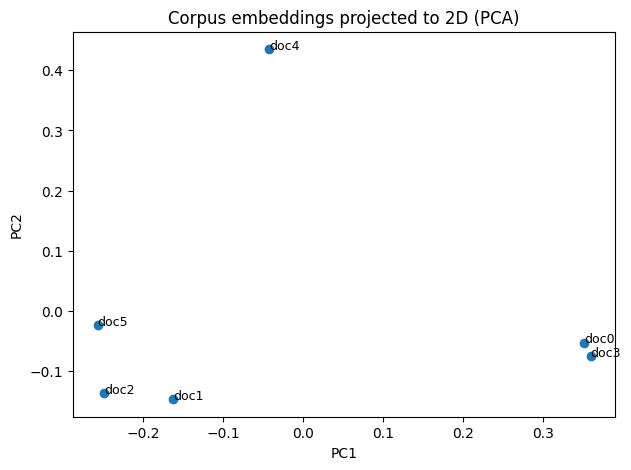

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(doc_vecs)

plt.figure(figsize=(7,5))
plt.scatter(Z[:,0], Z[:,1])
for i, txt in enumerate(corpus):
    plt.text(Z[i,0], Z[i,1], f"doc{i}", fontsize=9)
plt.title('Corpus embeddings projected to 2D (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# 6) Best practices, pitfalls, and “gotchas”

## Tokenization
- **Never assume** 1 word = 1 token.
- Use model-specific encodings when possible.
- Chunk by tokens, not characters.

## Embeddings
- Prefer **cosine similarity** for ranking.
- Embed **query and documents** with the same embeddings model.
- Normalize/clean text lightly; test changes empirically.
- Store metadata (doc_id, section, chunk index, token_count).

## Security
- Keep keys in environment variables or Key Vault.
- Rotate keys if exposed.

## Cost control
- Cache embeddings for documents; only embed new/changed chunks.
- Avoid embedding huge documents without chunking.


# 7) Cleanup

If you created any Azure resources specifically for this lab (storage, search, etc.), delete them.

For this notebook, the main “resource” is the Azure OpenAI deployment you are calling.
No additional resources are created by default.
